<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/ML_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scikit Learn Pipelines


---


Pipelines chains together multiple steps so that the output of each step is used
as input to the next step.
Pipelines makes it easy to apply the same preprocessing to train and test!

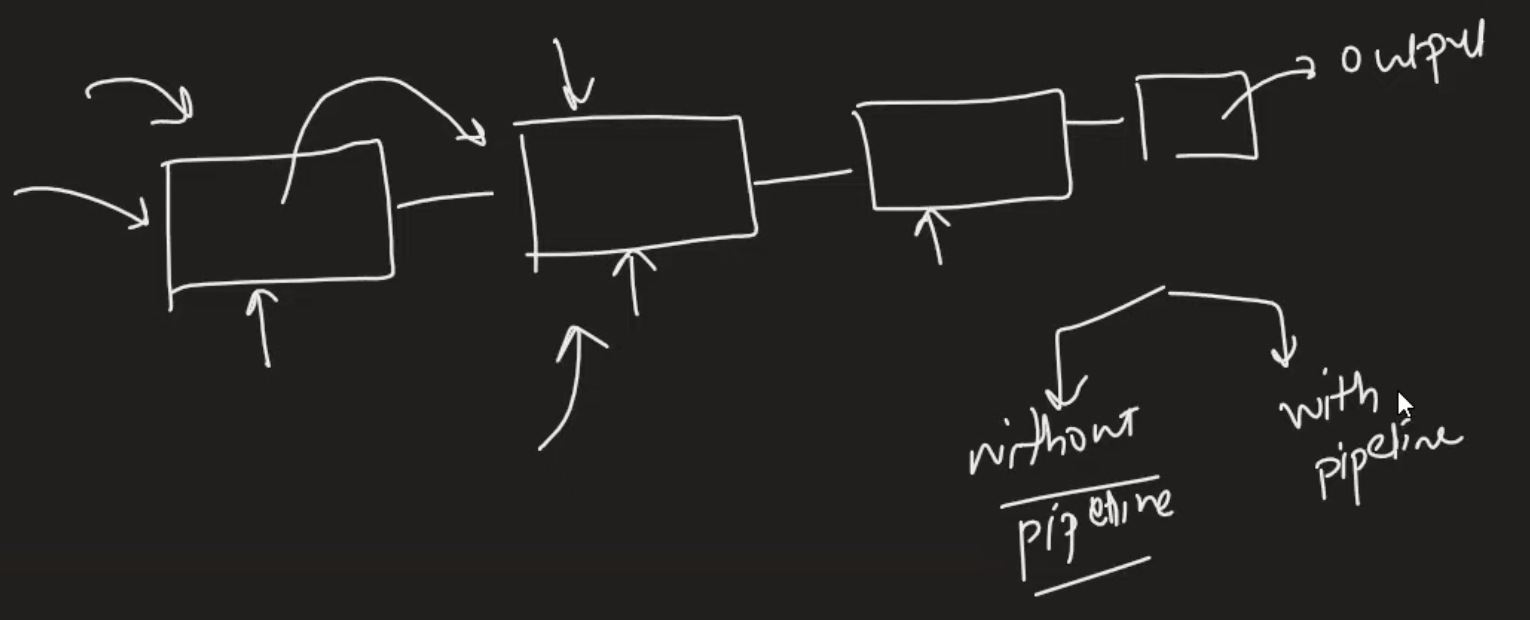

# Titanic Without Pipelines

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day29-sklearn-pipelines/train.csv')

In [5]:
df.drop(columns=['PassengerId', 'Name', 'Ticket','Cabin'], inplace=True)

In [6]:
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [9]:
# Step 1 -> train/test/split
X_train,X_test,y_train, y_test = train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2, random_state=42)

In [11]:
X_train.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5,S
733,2,male,23.0,0,0,13.0,S


In [27]:
y_train

,Survived
331,0
733,0
382,0
704,0
813,0
...,...
106,1
270,0
860,0
435,1


In [12]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [14]:
# Applying imputation

si_age = SimpleImputer()
si_embarked = SimpleImputer(strategy='most_frequent')

X_train_age = si_age.fit_transform(X_train[['Age']])
X_train_embarked = si_embarked.fit_transform(X_train[['Embarked']])

X_test_age = si_age.transform(X_test[['Age']])
X_test_embarked = si_embarked.transform(X_test[['Embarked']])


In [17]:
# one hot encoding Sex and Embarked
ohe_sex = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
ohe_embarked = OneHotEncoder(sparse_output=False,handle_unknown='ignore')

X_train_sex = ohe_sex.fit_transform(X_train[['Sex']])
X_train_embarked = ohe_embarked.fit_transform(X_train_embarked)

X_test_sex = ohe_sex.transform(X_test[['Sex']])
X_test_embarked = ohe_embarked. transform(X_test_embarked)

In [19]:
X_train_embarked

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

In [20]:
X_train_rem = X_train.drop(columns=['Sex', 'Age', 'Embarked'])
X_test_rem = X_test.drop(columns=['Sex', 'Age', 'Embarked'])

In [24]:
X_train_transformed = np.concatenate((X_train_rem, X_train_age, X_train_sex, X_train_embarked), axis=1)
X_test_transformed = np.concatenate((X_test_rem, X_test_age, X_test_sex, X_test_embarked), axis=1)

In [25]:
X_test_transformed.shape

(179, 10)

In [26]:
# Classifier

clf = DecisionTreeClassifier()
clf.fit(X_train_transformed, y_train)

DecisionTreeClassifier()

In [30]:
y_pred = clf.predict(X_test_transformed)
y_pred

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1])

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.776536312849162

In [31]:
import pickle

In [35]:
pickle.dump(ohe_sex, open('models/ohe_sex.pkl', 'wb'))
pickle.dump(ohe_embarked, open('models/ohe_embarked.pkl', 'wb'))
pickle.dump(clf, open('models/clf.pkl', 'wb'))



---



# Predict without pipeline

In [36]:
import pickle
import numpy as np

In [38]:
ohe_sex = pickle.load(open('models/ohe_sex.pkl', 'rb'))
ohe_embarked = pickle.load(open('models/ohe_embarked.pkl', 'rb'))
clf = pickle.load(open('models/clf.pkl', 'rb'))

In [39]:
test_input = np.array([2,'male',31.0, 0, 0, 10.5, 'S'], dtype='object').reshape(1,7)

In [40]:
test_input

array([[2, 'male', 31.0, 0, 0, 10.5, 'S']], dtype=object)

In [41]:
test_input_sex = ohe_sex.transform(test_input[:,1].reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [45]:
test_input_sex

array([[0., 1.]])

In [44]:
test_input_embarked = ohe_embarked.transform(test_input[:,-1].reshape(1,1))

In [46]:
test_input_embarked

array([[0., 0., 1.]])

In [47]:
test_input_age = test_input[:,2].reshape(1,1)

In [48]:
test_input_transformed = np.concatenate((test_input[:,[0,3,4,5]], test_input_age, test_input_sex, test_input_embarked), axis=1)

In [50]:
test_input_transformed

array([[2, 0, 0, 10.5, 31.0, 0.0, 1.0, 0.0, 0.0, 1.0]], dtype=object)

In [51]:
clf.predict(test_input_transformed)

array([1])

# USING PIPELINES



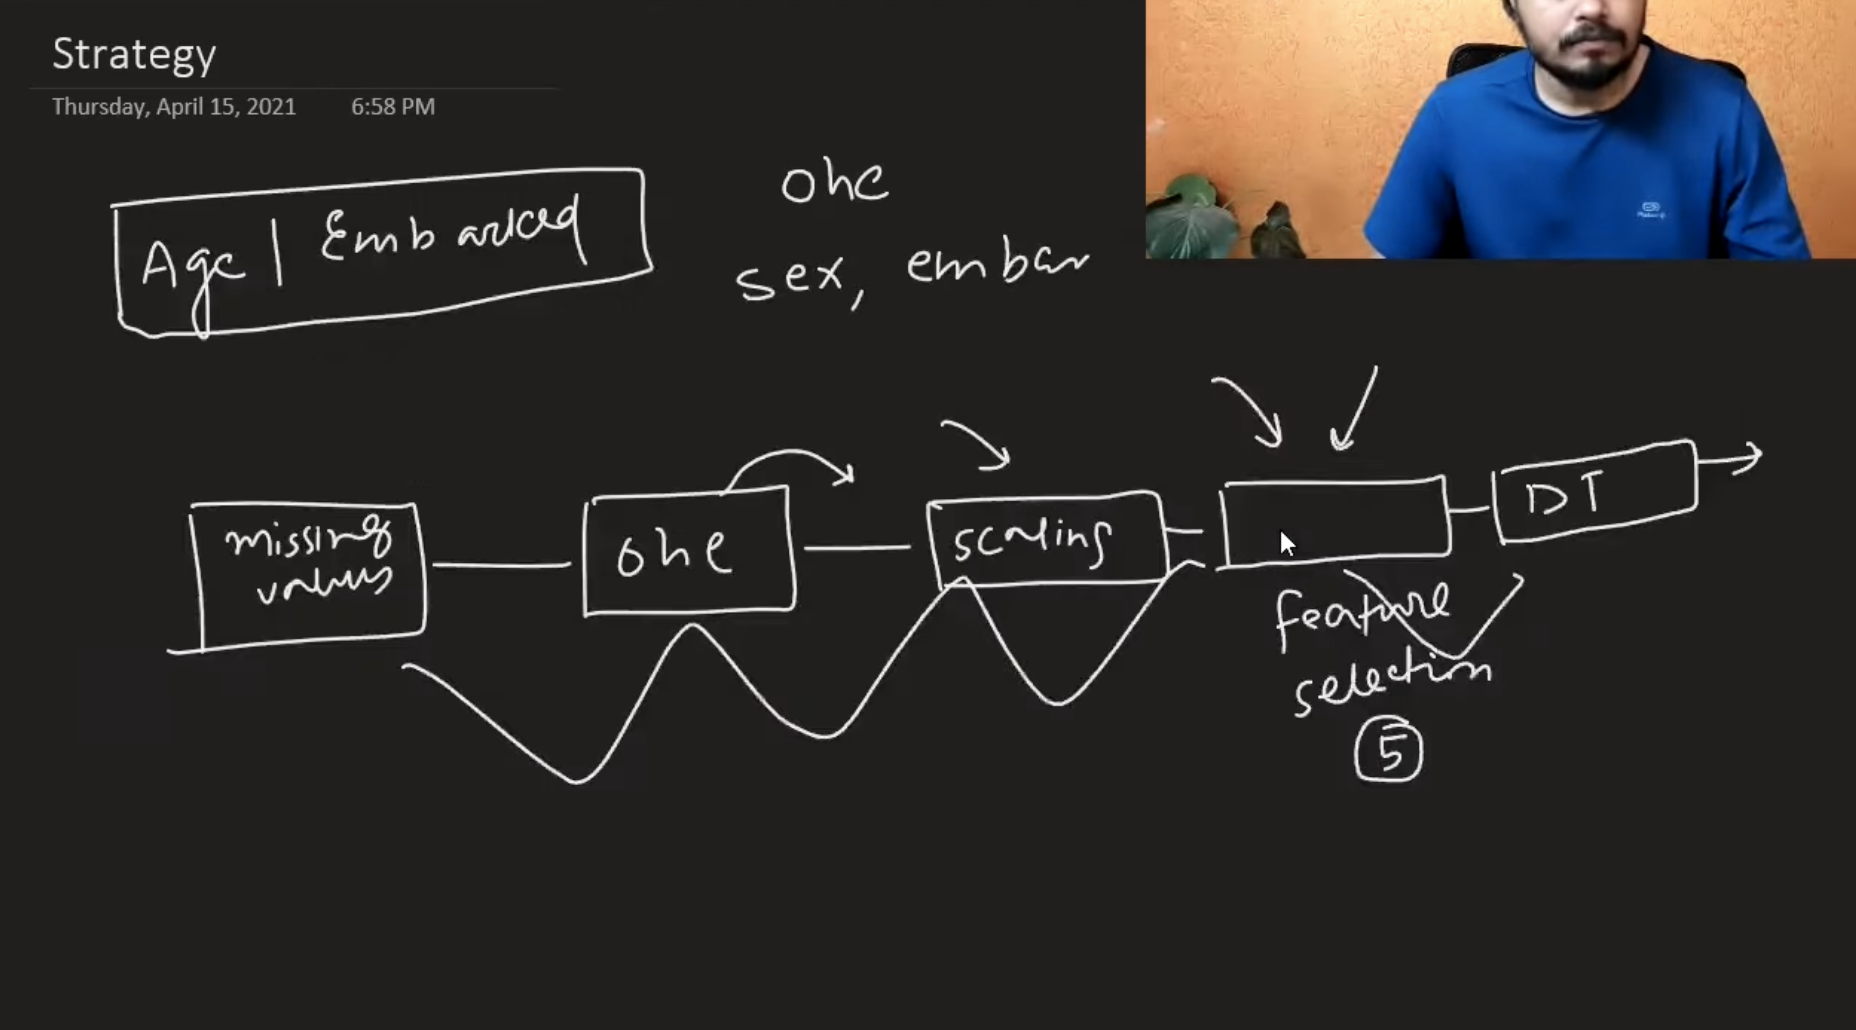

In [61]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import MinMaxScaler

from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.feature_selection import SelectKBest, chi2

from sklearn.tree import DecisionTreeClassifier


In [54]:
# df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace = True)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Survived']), df['Survived'], test_size=0.2, random_state=42)

In [56]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S


In [64]:
# imputation transformer
trf1 = ColumnTransformer([
    ('impute_age', SimpleImputer(),[2]), # call by column index value because if name -> df nhi numpy array when using in pipeline
    ('impute_embarked', SimpleImputer(strategy='most_frequent'), [6])
], remainder='passthrough')

In [65]:
# one hot transformer
trf2 = ColumnTransformer([
    ('ohe_sex_embarked', OneHotEncoder(sparse_output=False, handle_unknown='ignore'),[1,6])
], remainder='passthrough')

In [70]:
# Scaling
trf3 = ColumnTransformer([
    ('scale', MinMaxScaler(), slice(0,10)) # or 0:10 same thing all the columns
])

In [72]:
# Feature selection
trf4 = SelectKBest(score_func=chi2, k=8)

In [73]:
# train the model
# decision tree
trf5 = DecisionTreeClassifier()

In [82]:
pipe = Pipeline([
('trf1', trf1), ('trf2', trf2), ('trf3', trf3), ('trf4', trf4), ('trf5', trf5)
])

# Pipeline Vs make_pipeline

Pipeline requires naming of steps, make_pipeline does not.

(Same applies to ColumnTransformer vs make_column_transformer)

In [75]:
# Alternate Syntax
pipe = make_pipeline(trf1, trf2, trf3, trf4, trf5)

In [80]:
# train
pipe.fit(X_train, y_train) # use fit_transform if not giving for model training

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_age', SimpleImputer(),
                                                  [2]),
                                                 ('impute_embarked',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [6])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_sex_embarked',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 6])])),
                ('columntransformer-3',
                 ColumnTransformer(transformers=[('scale', MinMaxScaler(),
                                                  slice(0, 8, None))])),
                ('selectkbest',
                 SelectKBest(k=8,
                             score_func=<function chi2 at 0x7feaf8fc4e00>)),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

In [79]:
# Display pipeline

from sklearn import set_config
set_config(display='diagram')

In [83]:
pipe.named_steps

{'trf1': ColumnTransformer(remainder='passthrough',
                   transformers=[('impute_age', SimpleImputer(), [2]),
                                 ('impute_embarked',
                                  SimpleImputer(strategy='most_frequent'),
                                  [6])]),
 'trf2': ColumnTransformer(remainder='passthrough',
                   transformers=[('ohe_sex_embarked',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  [1, 6])]),
 'trf3': ColumnTransformer(transformers=[('scale', MinMaxScaler(), slice(0, 8, None))]),
 'trf4': SelectKBest(k=8, score_func=<function chi2 at 0x7feaf8fc4e00>),
 'trf5': DecisionTreeClassifier()}

In [84]:
y_pred = pipe.predict(X_test)

In [85]:
y_pred

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0])

In [86]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6256983240223464

# Cross Validation using Pipeline

In [88]:
# cross validation using cross_val_score
from sklearn.model_selection import cross_val_score
cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean()

np.float64(0.6391214419383433)

# GridSearch using pipeline

In [89]:
# gridsearchcv
params = {
    'trf5__max_depth': [1,2,3,4,5, None]
}


In [90]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('trf1',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('impute_age',
                                                                         SimpleImputer(),
                                                                         [2]),
                                                                        ('impute_embarked',
                                                                         SimpleImputer(strategy='most_frequent'),
                                                                         [6])])),
                                       ('trf2',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe_sex_embarked',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         [1,
                                                                          6])])),
                                       ('trf3',
                                        ColumnTransformer(transformers=[('scale',
                                                                         MinMaxScaler(),
                                                                         slice(0, 8, None))])),
                                       ('trf4',
                                        SelectKBest(k=8,
                                                    score_func=<function chi2 at 0x7feaf8fc4e00>)),
                                       ('trf5', DecisionTreeClassifier())]),
             param_grid={'trf5__max_depth': [1, 2, 3, 4, 5, None]},
             scoring='accuracy')

In [91]:
grid.best_params_

{'trf5__max_depth': 2}

# Exporting the pipeline

In [97]:
# export
import pickle
pickle.dump(pipe, open('pipe.pkl','wb'))

In [98]:
import pickle
import numpy as np
pipe = pickle.load(open('pipe.pkl', 'rb'))
# Assume user input
test_input2 = np.array([2, 'male', 31.0, 0, 0, 10.5, 'S'], dtype=object).reshape(1,7)
pipe.predict(test_input2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


array([0])